# Prueba de Progreso 2 - Clustering de patrones de tráfico en Gipuzkoa

**Autor:** Jorge López Gómez  
**Email:** [Jorge.Lopez32@alu.uclm.es](mailto:Jorge.Lopez32@alu.uclm.es)  
**Asignatura:** Técnicas de Aprendizaje Automático  
**Curso:** 2025/2026  
**Universidad:** UCLM — Talavera de la Reina  
**Fecha:** Abril 2026  
**Repositorio:** [github.com/JorgeLopezGomez/ML-TA-2025-2026-JorgeLopezGomez](https://github.com/JorgeLopezGomez/ML-TA-2025-2026-JorgeLopezGomez)

## Índice

1. [Introducción](#1.-introducción)  
2. [Carga e integración de los datos](#2.-carga-e-integración-de-los-datos)  
3. [Análisis exploratorio de los datos](#3.-análisis-exploratorio-de-los-datos)  
4. [Preprocesamiento](#4.-preprocesamiento)  
5. [Reducción de dimensionalidad mediante PCA](#5.-reducción-de-dimensionalidad-mediante-pca)  
6. [Aplicación de algoritmos de clustering](#6.-aplicación-de-algoritmos-de-clustering)  
7. [Comparación de resultados y selección del modelo final](#7.-comparación-de-resultados-y-selección-del-modelo-final)  
8. [Interpretación de los clústeres obtenidos](#8.-interpretación-de-los-clústeres-obtenidos)  
9. [Conclusiones finales](#9.-conclusiones-finales)  
10. [Bibliografía](#10.-bibliografía)

# 1. Introducción

En esta prueba de progreso se aborda un problema de **aprendizaje no supervisado** aplicado a datos de tráfico de carreteras de Gipuzkoa. El objetivo principal es **identificar patrones de comportamiento** y agrupar observaciones similares mediante técnicas de **clustering**, con el fin de obtener distintos perfiles de tráfico según la hora y la zona.

Para ello, se trabajará con tres conjuntos de datos correspondientes a la semana **20251020**: datos de **volumen**, datos de **velocidad** y datos de **estaciones**. Como estos ficheros presentan diferencias de formato y de identificadores, primero será necesario integrarlos correctamente en una única tabla de trabajo.

A partir de ahí, se realizará un análisis exploratorio, un preprocesamiento de los datos, una reducción de dimensionalidad mediante **PCA** y, finalmente, se aplicarán y compararán los algoritmos **K-Means**, **DBSCAN** y **Agglomerative Clustering**. El objetivo no será solo obtener agrupaciones, sino también **interpretarlas y justificar cuál de los tres métodos resulta más adecuado** para este problema.

# 2. Carga e integración de los datos

En este apartado se cargan los tres ficheros proporcionados para la semana **20251020**: volumen, velocidad y estaciones. El objetivo es preparar una única tabla de trabajo que reúna toda la información disponible.

Esta integración requiere un pequeño tratamiento previo, ya que los datos de **volumen** están organizados por horas, mientras que los de **velocidad** se registran cada media hora. Además, para relacionar ambos conjuntos es necesario utilizar el fichero de **estaciones**, que actúa como nexo entre los identificadores y aporta también información geográfica útil para la interpretación posterior de los resultados.

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [162]:
# Localización flexible de carpetas
BASE_DIR = Path.cwd().resolve()

if (BASE_DIR / "Semana(20251020)").exists():
    SEMANA_DIR = BASE_DIR / "Semana(20251020)"
    RESULTADO_DIR = BASE_DIR / "ResultadoFinal"
elif (BASE_DIR.parent / "Semana(20251020)").exists():
    SEMANA_DIR = BASE_DIR.parent / "Semana(20251020)"
    RESULTADO_DIR = BASE_DIR
else:
    SEMANA_DIR = Path("/mnt/data")
    RESULTADO_DIR = Path("/mnt/data")

RESULTADO_DIR.mkdir(parents=True, exist_ok=True)

VOLUMEN_PATH = SEMANA_DIR / "20251020_datosvolumen.csv"
VELOCIDAD_PATH = SEMANA_DIR / "20251020_datosvelocidad.csv"
ESTACIONES_PATH = SEMANA_DIR / "estaciones.csv"

CSV_INTEGRADO_PATH = RESULTADO_DIR / "datos_trafico_20251020.csv"
CSV_RESULTADOS_PATH = RESULTADO_DIR / "20251020_resultados_clustering.csv"

print("Carpeta de datos:", SEMANA_DIR)
print("Carpeta de salida:", RESULTADO_DIR)

Carpeta de datos: /home/jorgegmen/Documentos/GitHub/ML-TA-2025-2026-JorgeLopezGomez/P2_Clustering/Semana(20251020)
Carpeta de salida: /home/jorgegmen/Documentos/GitHub/ML-TA-2025-2026-JorgeLopezGomez/P2_Clustering/ResultadoFinal


In [163]:
# Carga de datos
columnas_estaciones = [
    "Road", "ETD code", "System code", "Description", "Country code", "Country",
    "Municipality code", "Municipality", "Territory code", "Territory",
    "Postal code", "GPSX", "GPSY", "X", "Y", "drop"
]

df_volumen = pd.read_csv(VOLUMEN_PATH, sep=";", skipinitialspace=True)

df_velocidad = pd.read_csv(
    VELOCIDAD_PATH,
    sep=";",
    encoding="ISO-8859-1",
    skipinitialspace=True
).drop(columns=["Unnamed: 13"], errors="ignore")

df_estaciones = pd.read_csv(
    ESTACIONES_PATH,
    sep=";",
    encoding="ISO-8859-1",
    header=0,
    names=columnas_estaciones,
    engine="python",
    skipinitialspace=True
).drop(columns=["drop"])

for df in [df_volumen, df_velocidad, df_estaciones]:
    df.columns = [col.strip() for col in df.columns]
    for col in df.select_dtypes(include=["object", "str"]).columns:
        df[col] = df[col].str.strip()

In [164]:
print("Dimensiones volumen:", df_volumen.shape)
print("Dimensiones velocidad:", df_velocidad.shape)
print("Dimensiones estaciones:", df_estaciones.shape)

display(df_volumen.head())
display(df_velocidad.head())
display(df_estaciones.head())

Dimensiones volumen: (12840, 15)
Dimensiones velocidad: (80410, 13)
Dimensiones estaciones: (85, 15)


,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados
0,1,20/10/2025,01:00,27,3,0,0,0,0,15,1,8,0,0,0
1,1,20/10/2025,02:00,16,2,0,0,0,0,4,1,3,0,0,0
2,1,20/10/2025,03:00,10,1,0,0,0,0,8,0,3,0,0,0
3,1,20/10/2025,04:00,8,2,0,0,0,0,6,0,1,0,0,0
4,1,20/10/2025,05:00,22,2,0,0,0,0,9,0,10,1,0,0


,Fecha,Hora,Sistema,ETD,Detector,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales
0,2025-10-20,01:00:00 - 01:30:00,AP-8,"[AP-8] 257-ETD FRANCIA-BILBAO, AP-8 pk 0,000, ...",Central FRANCIA,0,2,1,0,"76,67",3,0,3
1,2025-10-20,01:00:00 - 01:30:00,AP-8,"[AP-8] 257-ETD FRANCIA-BILBAO, AP-8 pk 0,000, ...",Central BILBAO,0,2,7,0,"92,22",9,0,9
2,2025-10-20,01:00:00 - 01:30:00,AP-8,"[AP-8] 257-ETD FRANCIA-BILBAO, AP-8 pk 0,000, ...",Lento BILBAO,2,67,21,0,"72,28",24,66,90
3,2025-10-20,01:00:00 - 01:30:00,AP-8,"[AP-8] 257-ETD FRANCIA-BILBAO, AP-8 pk 0,000, ...",Lento FRANCIA,9,49,4,0,"61,45",21,41,62
4,2025-10-20,01:00:00 - 01:30:00,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",Lento ASTIGARRAGA,0,12,2,0,70,13,1,14


,Road,ETD code,System code,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",108,España,NaN,NaN,20,Gipuzkoa,NaN,580428.65,4792191.27,-2.008765,43.278246
1,GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, G...",108,España,53.0,LEZO,20,Gipuzkoa,20100.0,594584.89,4798000.13,-1.833330,43.328896
2,N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",108,España,30.0,EIBAR,20,Gipuzkoa,20600.0,545592.28,4782339.10,-2.438889,43.192449
3,N-I,12,1,"[N-I] 12-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-I...",108,España,71.0,TOLOSA,20,Gipuzkoa,20400.0,575944.00,4778800.00,-2.065870,43.158142
4,GI-20,16,1,"[GI-20] 16-ETD USURBIL, AP-8-ERRENTERIA,AP-8, ...",108,España,69.0,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0.0,583607.00,4795202.00,-1.969142,43.305006


In [165]:
# Preparación de volumen
df_volumen["Fecha"] = pd.to_datetime(df_volumen["Fecha"], format="%d/%m/%Y")

df_volumen["Fecha_hora"] = (
    df_volumen["Fecha"] +
    pd.to_timedelta(df_volumen["Hora"].replace({"24:00": "00:00"}) + ":00")
)
df_volumen.loc[df_volumen["Hora"] == "24:00", "Fecha_hora"] += pd.Timedelta(days=1)

df_volumen["fecha_dia"] = df_volumen["Fecha_hora"].dt.date.astype(str)
df_volumen["hora_bloque"] = df_volumen["Fecha_hora"].dt.strftime("%H:00")
df_volumen["ETD code"] = df_volumen["Estacion"].astype(int)

for i in range(1, 7):
    df_volumen[f"Carril {i} total"] = df_volumen[f"Carril {i} ligeros"] + df_volumen[f"Carril {i} pesados"]

columnas_ligeros = [f"Carril {i} ligeros" for i in range(1, 7)]
columnas_pesados = [f"Carril {i} pesados" for i in range(1, 7)]

df_volumen["volumen_ligeros_total"] = df_volumen[columnas_ligeros].sum(axis=1)
df_volumen["volumen_pesados_total"] = df_volumen[columnas_pesados].sum(axis=1)
df_volumen["volumen_total"] = df_volumen["volumen_ligeros_total"] + df_volumen["volumen_pesados_total"]

In [166]:
# Preparación de velocidad
df_velocidad["Fecha"] = pd.to_datetime(df_velocidad["Fecha"])
df_velocidad["hora_inicio_raw"] = df_velocidad["Hora"].str.split(" - ").str[0]

df_velocidad["hora_inicio_std"] = df_velocidad["hora_inicio_raw"].replace({
    "24:00:00": "00:00:00",
    "24:30:00": "00:30:00"
})

df_velocidad["Fecha_hora"] = df_velocidad["Fecha"] + pd.to_timedelta(df_velocidad["hora_inicio_std"])
df_velocidad.loc[df_velocidad["hora_inicio_raw"].str.startswith("24:"), "Fecha_hora"] += pd.Timedelta(days=1)

df_velocidad["fecha_dia"] = df_velocidad["Fecha_hora"].dt.date.astype(str)
df_velocidad["hora_bloque"] = df_velocidad["Fecha_hora"].dt.strftime("%H:00")

df_velocidad["Velocidad media (km/h)"] = (
    df_velocidad["Velocidad media (km/h)"].str.replace(",", ".", regex=False).astype(float)
)

df_velocidad["ETD code"] = (
    df_velocidad["ETD"].str.extract(r"\]\s*(\d+)-ETD")[0].astype(int)
)

Como los datos de velocidad están registrados cada media hora, se agregan a nivel horario para poder combinarlos con los de volumen. En esta agregación se suman los recuentos y la velocidad media se calcula como una media ponderada por número de vehículos.

In [167]:
# Agregación horaria de velocidad
columnas_suma = [
    "0-50 (km/h)", "50-80 (km/h)", "80-120 (km/h)", "120-255 (km/h)",
    "0-6 (m)", "6-999 (m)", "Vehículos totales"
]

def media_ponderada_velocidad(x):
    pesos = df_velocidad.loc[x.index, "Vehículos totales"]
    if pesos.sum() > 0:
        return np.average(x, weights=pesos)
    return x.mean()

agregaciones = {col: "sum" for col in columnas_suma}
agregaciones["Velocidad media (km/h)"] = media_ponderada_velocidad
agregaciones["Sistema"] = "first"
agregaciones["ETD"] = "first"

df_velocidad_hora = (
    df_velocidad
    .groupby(["fecha_dia", "hora_bloque", "ETD code"], as_index=False)
    .agg(agregaciones)
    .rename(columns={"Velocidad media (km/h)": "Velocidad media horaria (km/h)"})
)

df_velocidad_hora["num_registros_velocidad_hora"] = (
    df_velocidad.groupby(["fecha_dia", "hora_bloque", "ETD code"]).size().values
)

In [168]:
# Integración final
df_trafico = df_volumen.merge(df_estaciones, on="ETD code", how="left")

df_trafico = df_trafico.merge(
    df_velocidad_hora,
    on=["fecha_dia", "hora_bloque", "ETD code"],
    how="left",
    suffixes=("", "_vel")
)

df_trafico = df_trafico.sort_values(["ETD code", "Fecha_hora"]).reset_index(drop=True)
df_trafico.to_csv(CSV_INTEGRADO_PATH, index=False)

print("Dimensiones del dataset final:", df_trafico.shape)
display(df_trafico.head())

display(df_trafico.isna().sum().sort_values(ascending=False).head(10).to_frame("nulos"))
print("Número de filas duplicadas:", df_trafico.duplicated().sum())
print("CSV integrado guardado en:", CSV_INTEGRADO_PATH)

Dimensiones del dataset final: (12840, 53)


,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,...,50-80 (km/h),80-120 (km/h),120-255 (km/h),0-6 (m),6-999 (m),Vehículos totales,Velocidad media horaria (km/h),Sistema,ETD,num_registros_velocidad_hora
0,1,2025-10-20,01:00,27,3,0,0,0,0,15,...,45.0,7.0,0.0,50.0,4.0,54.0,68.056296,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
1,1,2025-10-20,02:00,16,2,0,0,0,0,4,...,19.0,1.0,0.0,23.0,3.0,26.0,57.115385,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
2,1,2025-10-20,03:00,10,1,0,0,0,0,8,...,15.0,5.0,0.0,21.0,1.0,22.0,69.319091,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
3,1,2025-10-20,04:00,8,2,0,0,0,0,6,...,12.0,2.0,0.0,15.0,2.0,17.0,62.057647,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
4,1,2025-10-20,05:00,22,2,0,0,0,0,9,...,36.0,5.0,0.0,41.0,3.0,44.0,66.249773,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0


,nulos
Municipality code,2976
Municipality,2976
Postal code,2976
6-999 (m),205
num_registros_velocidad_hora,205
Vehículos totales,205
Sistema,205
50-80 (km/h),205
0-50 (km/h),205
Velocidad media horaria (km/h),205


Número de filas duplicadas: 0
CSV integrado guardado en: /home/jorgegmen/Documentos/GitHub/ML-TA-2025-2026-JorgeLopezGomez/P2_Clustering/ResultadoFinal/datos_trafico_20251020.csv


# 3. Análisis exploratorio de los datos

Una vez construida la tabla unificada, en este apartado se realiza un análisis exploratorio con el objetivo de comprender mejor la estructura del conjunto de datos, detectar posibles problemas de calidad y observar patrones iniciales que puedan resultar útiles en las fases posteriores del trabajo.

In [169]:
print("Dimensiones del dataset:", df_trafico.shape)
display(df_trafico.head())
df_trafico.info()

Dimensiones del dataset: (12840, 53)


,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,...,50-80 (km/h),80-120 (km/h),120-255 (km/h),0-6 (m),6-999 (m),Vehículos totales,Velocidad media horaria (km/h),Sistema,ETD,num_registros_velocidad_hora
0,1,2025-10-20,01:00,27,3,0,0,0,0,15,...,45.0,7.0,0.0,50.0,4.0,54.0,68.056296,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
1,1,2025-10-20,02:00,16,2,0,0,0,0,4,...,19.0,1.0,0.0,23.0,3.0,26.0,57.115385,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
2,1,2025-10-20,03:00,10,1,0,0,0,0,8,...,15.0,5.0,0.0,21.0,1.0,22.0,69.319091,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
3,1,2025-10-20,04:00,8,2,0,0,0,0,6,...,12.0,2.0,0.0,15.0,2.0,17.0,62.057647,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0
4,1,2025-10-20,05:00,22,2,0,0,0,0,9,...,36.0,5.0,0.0,41.0,3.0,44.0,66.249773,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",6.0


<class 'pandas.DataFrame'>
RangeIndex: 12840 entries, 0 to 12839
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Estacion                        12840 non-null  int64         
 1   Fecha                           12840 non-null  datetime64[us]
 2   Hora                            12840 non-null  str           
 3   Carril 1 ligeros                12840 non-null  int64         
 4   Carril 1 pesados                12840 non-null  int64         
 5   Carril 2 ligeros                12840 non-null  int64         
 6   Carril 2 pesados                12840 non-null  int64         
 7   Carril 3 ligeros                12840 non-null  int64         
 8   Carril 3 pesados                12840 non-null  int64         
 9   Carril 4 ligeros                12840 non-null  int64         
 10  Carril 4 pesados                12840 non-null  int64         
 11  Carril 5 lige

In [170]:
display(df_trafico[[
    "volumen_total", "volumen_ligeros_total", "volumen_pesados_total",
    "Vehículos totales", "Velocidad media horaria (km/h)", "X", "Y"
]].describe().T)

display(df_trafico.isna().sum().sort_values(ascending=False).head(15).to_frame("nulos"))

,count,mean,std,min,25%,50%,75%,max
volumen_total,12840.0,962.729984,1194.755909,0.000000,96.000000,450.000000,1378.000000,7214.000000
volumen_ligeros_total,12840.0,856.548520,1082.274548,0.000000,72.000000,403.000000,1247.250000,6832.000000
volumen_pesados_total,12840.0,106.181464,163.460813,0.000000,7.000000,37.000000,121.000000,1102.000000
Vehículos totales,12635.0,978.344598,1198.052718,1.000000,106.000000,472.000000,1406.000000,7214.000000
Velocidad media horaria (km/h),12635.0,70.801247,21.336118,25.000000,57.884589,71.502000,87.286979,110.527263
X,12840.0,-2.081677,0.223063,-2.538291,-2.260914,-2.017061,-1.942254,-1.734178
Y,12840.0,43.220801,0.107261,42.967972,43.128024,43.266142,43.306412,43.364450


,nulos
Municipality code,2976
Municipality,2976
Postal code,2976
6-999 (m),205
num_registros_velocidad_hora,205
Vehículos totales,205
Sistema,205
50-80 (km/h),205
0-50 (km/h),205
Velocidad media horaria (km/h),205


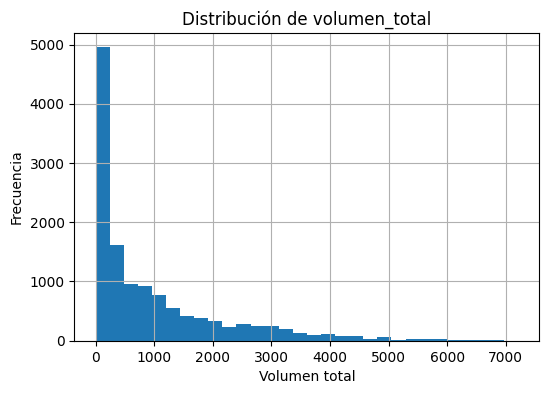

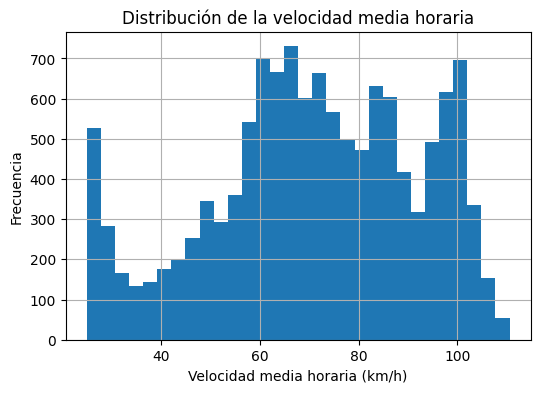

In [171]:
plt.figure(figsize=(6,4))
df_trafico["volumen_total"].hist(bins=30)
plt.title("Distribución de volumen_total")
plt.xlabel("Volumen total")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(6,4))
df_trafico["Velocidad media horaria (km/h)"].hist(bins=30)
plt.title("Distribución de la velocidad media horaria")
plt.xlabel("Velocidad media horaria (km/h)")
plt.ylabel("Frecuencia")
plt.show()

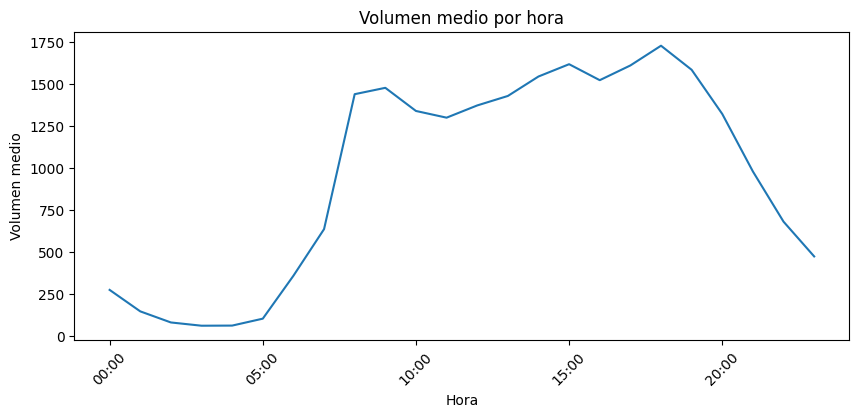

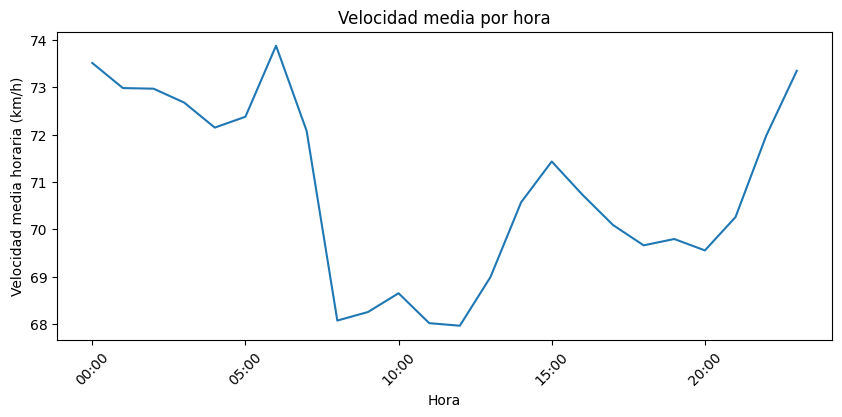

In [172]:
volumen_por_hora = df_trafico.groupby("hora_bloque")["volumen_total"].mean().sort_index()
velocidad_por_hora = df_trafico.groupby("hora_bloque")["Velocidad media horaria (km/h)"].mean().sort_index()

plt.figure(figsize=(10,4))
volumen_por_hora.plot()
plt.title("Volumen medio por hora")
plt.xlabel("Hora")
plt.ylabel("Volumen medio")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
velocidad_por_hora.plot()
plt.title("Velocidad media por hora")
plt.xlabel("Hora")
plt.ylabel("Velocidad media horaria (km/h)")
plt.xticks(rotation=45)
plt.show()

,volumen_medio
ETD code,
116,3038.380952
277,2960.654762
117,2714.273810
250,2696.809524
101,2403.972222
69,2254.636905
96,2169.815476
247,2166.761905
253,2144.166667


,velocidad_media
ETD code,
77,25.378273
62,27.642245
256,28.968181
206,29.301052
9136,31.232363
295,31.421902
55,34.973742
102,41.064548
258,44.314025


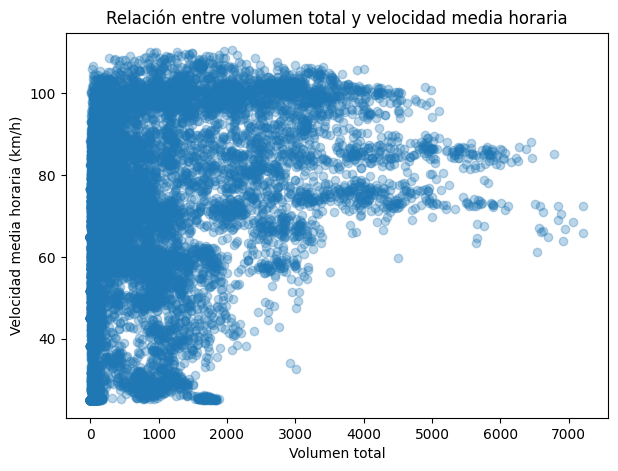

In [173]:
top_volumen = df_trafico.groupby("ETD code")["volumen_total"].mean().sort_values(ascending=False).head(10)
top_baja_velocidad = df_trafico.groupby("ETD code")["Velocidad media horaria (km/h)"].mean().sort_values().head(10)

display(top_volumen.to_frame("volumen_medio"))
display(top_baja_velocidad.to_frame("velocidad_media"))

df_rel = df_trafico[["volumen_total", "Velocidad media horaria (km/h)"]].dropna()

plt.figure(figsize=(7,5))
plt.scatter(df_rel["volumen_total"], df_rel["Velocidad media horaria (km/h)"], alpha=0.3)
plt.title("Relación entre volumen total y velocidad media horaria")
plt.xlabel("Volumen total")
plt.ylabel("Velocidad media horaria (km/h)")
plt.show()

En esta fase ya se aprecia que el tráfico no es homogéneo ni entre horas ni entre estaciones. Además, los nulos se concentran en pocas variables concretas, lo que hace posible tratarlos más adelante sin comprometer el conjunto de datos integrado.

# 4. Preprocesamiento

El objetivo de este apartado es preparar una versión del dataset matemáticamente robusta para aplicar clustering. Para ello, el fichero integrado original se mantiene intacto, pero se construye una tabla de modelado especial en la que se calculan variables derivadas (porcentajes y ciclos horarios), se **elimina la multicolinealidad** filtrando características redundantes, y se realiza una **imputación avanzada de nulos** tras haber escalado el espacio, con el objetivo de preservar intacta la malla de ubicaciones y horarios.

In [174]:
df_model = df_trafico.copy()

df_model["Fecha_hora"] = pd.to_datetime(df_model["Fecha_hora"])
df_model["hora_num"] = df_model["Fecha_hora"].dt.hour
df_model["hora_sin"] = np.sin(2 * np.pi * df_model["hora_num"] / 24)
df_model["hora_cos"] = np.cos(2 * np.pi * df_model["hora_num"] / 24)

columnas_numericas_base = [
    "volumen_total", "volumen_ligeros_total", "volumen_pesados_total",
    "Vehículos totales", "Velocidad media horaria (km/h)",
    "0-50 (km/h)", "50-80 (km/h)", "80-120 (km/h)", "120-255 (km/h)",
    "X", "Y"
]

for col in columnas_numericas_base:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model["pct_pesados"] = df_model["volumen_pesados_total"] / df_model["volumen_total"].replace(0, np.nan)
for tramo in ["0-50", "50-80", "80-120", "120-255"]:
    df_model[f"pct_{tramo}"] = df_model[f"{tramo} (km/h)"] / df_model["Vehículos totales"].replace(0, np.nan)

duplicados_modelo = df_model.duplicated().sum()
df_model = df_model.drop_duplicates().reset_index(drop=True)
print("Duplicados eliminados en la tabla de modelado:", duplicados_modelo)

Duplicados eliminados en la tabla de modelado: 0


In [175]:
# ALERTA MATEMÁTICA CORREGIDA: Eliminamos la Multicolinealidad Perfecta.
# Meter volumen_ligeros y volumen_pesados al mismo tiempo que volumen_total y pct_pesados
# provoca que la varianza en el PCA y la distancia en KMeans estén hiper-dominadas por el simple conteo de coches.
# Al dejar solo `volumen_total` y `pct_pesados`, el modelo tiene TODA la info: cuántos son y en qué proporción.
# Igual con las velocidades, nos quedamos con tramos clave (0-50 y 80-120) para evitar la trampa de variables variables ficticias (una suma forzada a 1).

feature_cols = [
    "volumen_total",
    "Velocidad media horaria (km/h)",
    "pct_pesados",
    "pct_0-50",
    "pct_80-120",
    "X",
    "Y",
    "hora_sin",
    "hora_cos"
]

df_features = df_model[feature_cols].replace([np.inf, -np.inf], np.nan)
display(df_features.isna().sum().to_frame("nulos_antes_imputacion"))

,nulos_antes_imputacion
volumen_total,0
Velocidad media horaria (km/h),205
pct_pesados,205
pct_0-50,205
pct_80-120,205
X,0
Y,0
hora_sin,0
hora_cos,0


En lugar de modificar el CSV final integrado eliminando filas con valores nulos, aplicamos una estrategia de **imputación** para preservar observaciones clave.

Dado que este análisis trata sobre el tráfico en diferentes carreteras de Gipuzkoa, un valor nulo en velocidad o coordenadas puede indicar, por ejemplo, que no pasaron vehículos en ese tramo horario o que la estación no registra velocidad por ser una zona interurbana específica. Borrar estas filas supondría perder perfiles valiosos, por lo que usaremos una imputación (por ejemplo, con vecinos más cercanos `KNNImputer`) que infiera los datos faltantes a partir de patrones de tráfico similares, reteniendo la estructura original del espacio-tiempo.

In [176]:
# 1. Tratamiento Suave de OUTLIERS. El IQR .quantile ignora con seguridad los NaNs y recorta bien.
columnas_clip = ["volumen_total", "Velocidad media horaria (km/h)"]

for col in columnas_clip:
    q1 = df_features[col].quantile(0.25)
    q3 = df_features[col].quantile(0.75)
    iqr = q3 - q1
    df_features[col] = df_features[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

# 2. ESCALADO DE DATOS (MinMaxScaler gestiona limpiamente NaNs y homogeniza para distancias)
# ¡EXTREMADAMENTE CRÍTICO PASAR MINMAX ANTES DEL KNNIMPUTER PARA QUE SEA JUSTA LA EUCLIDIANA!
scaler = MinMaxScaler()
X_scaled_con_nan = scaler.fit_transform(df_features)

# 3. IMPUTACIÓN ESPACIAL-TEMPORAL CON K-VECINOS ESPACIALES.
# Ahora sí: El cálculo de vecino más cercano usa un espacio (0-1) equitativo para volumen, hora, velocidad y GPS.
imputer = KNNImputer(n_neighbors=5, weights="distance")
X_scaled = imputer.fit_transform(X_scaled_con_nan)

# 4. Desescalamos solo para mantener un DataFrame explicativo e interpretable para la celda 8
df_features_clean = pd.DataFrame(
    scaler.inverse_transform(X_scaled), 
    columns=df_features.columns, 
    index=df_features.index
)

# Sustituimos los features imputados en nuestro DataFrame de Modelado
df_model_clean = df_model.copy()
for col in feature_cols:
    df_model_clean[col] = df_features_clean[col].values

print("Shape final imputado y escalado sin perder 1 sola fila:", X_scaled.shape)
print("Todas las variables ahora están en una escala justa y sin correlación tramposa antes de entrar a PCA.")

Shape final imputado y escalado sin perder 1 sola fila: (12840, 9)
Todas las variables ahora están en una escala justa y sin correlación tramposa antes de entrar a PCA.


# 5. Reducción de dimensionalidad mediante PCA

Antes de aplicar clustering, se utiliza PCA para reducir la dimensionalidad y concentrar la mayor parte de la variabilidad en un número menor de componentes. Esto ayuda tanto a simplificar el problema como a facilitar la visualización e interpretación posterior.

Número de componentes seleccionados: 5
Varianza explicada acumulada: 0.9138196844042229


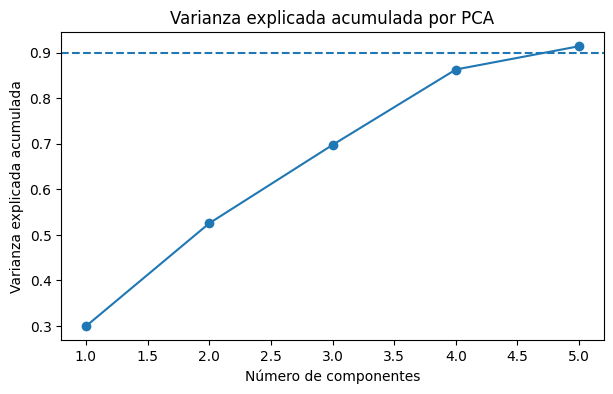

In [177]:
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

print("Número de componentes seleccionados:", pca.n_components_)
print("Varianza explicada acumulada:", var_acum[-1])

plt.figure(figsize=(7,4))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker="o")
plt.axhline(0.90, linestyle="--")
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.show()

In [178]:
pca_vis = PCA(n_components=2, random_state=42)
X_pca_2d = pca_vis.fit_transform(X_scaled)

df_pca_vis = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"], index=df_model_clean.index)
display(df_pca_vis.head())

,PC1,PC2
0,-0.228370,0.317837
1,-0.442530,0.254986
2,-0.209456,0.354672
3,-0.349102,0.281987
4,-0.271747,0.270535


# 6. Aplicación de algoritmos de clustering

En este trabajo se comparan tres enfoques distintos: **K-Means**, **DBSCAN** y **Agglomerative Clustering**. Para que la comparación sea homogénea, los tres se aplican sobre el espacio transformado por PCA.

In [179]:
def evaluar_clustering(X, labels, nombre):
    labels = np.asarray(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = float((labels == -1).mean()) if -1 in labels else 0.0

    if n_clusters < 2:
        return {
            "algoritmo": nombre,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    valid = labels != -1
    X_eval = X[valid]
    labels_eval = labels[valid]

    return {
        "algoritmo": nombre,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval)
    }

In [180]:
# 6.1 K-Means
resultados_kmeans = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    met = evaluar_clustering(X_pca, labels, f"KMeans (k={k})")
    met["parametro"] = k
    resultados_kmeans.append(met)

df_kmeans = pd.DataFrame(resultados_kmeans).sort_values("silhouette", ascending=False)
display(df_kmeans)

,algoritmo,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,parametro
3,KMeans (k=5),5,0.0,0.255857,1.333747,3624.449196,5
2,KMeans (k=4),4,0.0,0.249907,1.412605,3888.472177,4
4,KMeans (k=6),6,0.0,0.245058,1.360289,3457.051929,6
1,KMeans (k=3),3,0.0,0.235162,1.526750,3923.768372,3
0,KMeans (k=2),2,0.0,0.219670,1.759331,3984.824098,2


In [181]:
# 6.2 DBSCAN
resultados_dbscan = []
for eps in [0.10, 0.12, 0.15, 0.18]:
    for min_samples in [8, 12, 16]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)
        met = evaluar_clustering(X_pca, labels, f"DBSCAN (eps={eps}, min_samples={min_samples})")
        met["parametro"] = f"eps={eps}, min_samples={min_samples}"
        resultados_dbscan.append(met)

df_dbscan = pd.DataFrame(resultados_dbscan).sort_values("silhouette", ascending=False, na_position="last")
display(df_dbscan)

,algoritmo,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,parametro
9,"DBSCAN (eps=0.18, min_samples=8)",2,0.004984,0.239049,1.054219,377.276481,"eps=0.18, min_samples=8"
2,"DBSCAN (eps=0.1, min_samples=16)",95,0.702336,0.226711,0.990577,855.289120,"eps=0.1, min_samples=16"
11,"DBSCAN (eps=0.18, min_samples=16)",3,0.015654,0.174953,1.992828,334.102219,"eps=0.18, min_samples=16"
6,"DBSCAN (eps=0.15, min_samples=8)",3,0.013941,0.173816,1.990391,331.280283,"eps=0.15, min_samples=8"
10,"DBSCAN (eps=0.18, min_samples=12)",3,0.007399,0.171854,1.995358,331.050459,"eps=0.18, min_samples=12"
1,"DBSCAN (eps=0.1, min_samples=12)",178,0.514564,0.128949,1.035885,407.476991,"eps=0.1, min_samples=12"
0,"DBSCAN (eps=0.1, min_samples=8)",247,0.336682,0.040321,1.035554,280.041939,"eps=0.1, min_samples=8"
5,"DBSCAN (eps=0.12, min_samples=16)",79,0.419393,-0.194097,1.063990,197.365687,"eps=0.12, min_samples=16"
4,"DBSCAN (eps=0.12, min_samples=12)",113,0.269081,-0.232507,1.133354,176.076761,"eps=0.12, min_samples=12"
7,"DBSCAN (eps=0.15, min_samples=12)",11,0.031620,-0.256736,1.370449,106.113349,"eps=0.15, min_samples=12"


In [182]:
# 6.3 Agglomerative Clustering
resultados_agg = []
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_pca)
    met = evaluar_clustering(X_pca, labels, f"Agglomerative (k={k})")
    met["parametro"] = k
    resultados_agg.append(met)

df_agg = pd.DataFrame(resultados_agg).sort_values("silhouette", ascending=False)
display(df_agg)

,algoritmo,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,parametro
2,Agglomerative (k=4),4,0.0,0.201846,1.525540,2942.439697,4
3,Agglomerative (k=5),5,0.0,0.190277,1.500045,2854.429475,5
1,Agglomerative (k=3),3,0.0,0.185797,1.684258,2716.142485,3
4,Agglomerative (k=6),6,0.0,0.180362,1.560188,2718.637071,6
0,Agglomerative (k=2),2,0.0,0.168896,1.922928,2564.758317,2


# 7. Comparación de resultados y selección del modelo final

La comparación no se basa solo en métricas internas, sino también en la facilidad para interpretar los grupos obtenidos. Por ello, además de revisar la *silhouette*, se valora si el algoritmo genera clústeres estables, si evita dejar demasiadas observaciones como ruido y si permite describir perfiles de tráfico claros.

In [183]:
mejor_kmeans = df_kmeans.iloc[0].copy()
mejor_dbscan = df_dbscan.iloc[0].copy()
mejor_agg = df_agg.iloc[0].copy()

comparativa = pd.DataFrame([mejor_kmeans, mejor_dbscan, mejor_agg])
comparativa = comparativa[["algoritmo", "parametro", "n_clusters", "noise_ratio",
                           "silhouette", "davies_bouldin", "calinski_harabasz"]]
display(comparativa.sort_values("silhouette", ascending=False, na_position="last"))

,algoritmo,parametro,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
3,KMeans (k=5),5,5,0.000000,0.255857,1.333747,3624.449196
9,"DBSCAN (eps=0.18, min_samples=8)","eps=0.18, min_samples=8",2,0.004984,0.239049,1.054219,377.276481
2,Agglomerative (k=4),4,4,0.000000,0.201846,1.525540,2942.439697


In [184]:
# Regla de selección: se penaliza DBSCAN si deja demasiado ruido y,
# si K-Means queda muy cerca del mejor resultado, se prioriza por interpretabilidad.
candidatos = comparativa.dropna(subset=["silhouette"]).copy()
candidatos = candidatos[candidatos["n_clusters"] >= 2]

candidatos_validos = candidatos.copy()
candidatos_validos = candidatos_validos[
    ~((candidatos_validos["algoritmo"].str.contains("DBSCAN")) & (candidatos_validos["noise_ratio"] > 0.35))
]

candidatos_validos = candidatos_validos.sort_values("silhouette", ascending=False).reset_index(drop=True)
mejor_global = candidatos_validos.iloc[0]

km_rows = candidatos_validos[candidatos_validos["algoritmo"].str.contains("KMeans")]
if not km_rows.empty and (mejor_global["silhouette"] - km_rows.iloc[0]["silhouette"] <= 0.02):
    modelo_final = km_rows.iloc[0]
else:
    modelo_final = mejor_global

display(modelo_final.to_frame("valor"))

,valor
algoritmo,KMeans (k=5)
parametro,5
n_clusters,5
noise_ratio,0.0
silhouette,0.255857
davies_bouldin,1.333747
calinski_harabasz,3624.449196


In [185]:
# Ajuste final del modelo seleccionado
nombre_final = modelo_final["algoritmo"]

if "KMeans" in nombre_final:
    k_final = int(modelo_final["parametro"])
    final_model = KMeans(n_clusters=k_final, random_state=42, n_init=20)
    final_labels = final_model.fit_predict(X_pca)

elif "Agglomerative" in nombre_final:
    k_final = int(modelo_final["parametro"])
    final_model = AgglomerativeClustering(n_clusters=k_final, linkage="ward")
    final_labels = final_model.fit_predict(X_pca)

else:
    param_str = modelo_final["parametro"]
    eps_final = float(param_str.split(",")[0].split("=")[1])
    min_samples_final = int(param_str.split(",")[1].split("=")[1])
    final_model = DBSCAN(eps=eps_final, min_samples=min_samples_final)
    final_labels = final_model.fit_predict(X_pca)

df_resultados = df_model_clean.copy()
df_resultados["cluster"] = final_labels
df_resultados["PC1"] = X_pca_2d[:, 0]
df_resultados["PC2"] = X_pca_2d[:, 1]

print("Algoritmo final seleccionado:", nombre_final)
print(df_resultados["cluster"].value_counts().sort_index())

Algoritmo final seleccionado: KMeans (k=5)
cluster
0    1777
1    3228
2    3182
3    2299
4    2354
Name: count, dtype: int64


# 8. Interpretación de los clústeres obtenidos

Una vez seleccionado el modelo final, el siguiente paso es describir qué representa cada grupo. Para ello, se combinan resúmenes estadísticos y visualizaciones sencillas que permitan observar diferencias en volumen, velocidad, composición del tráfico, localización y distribución temporal.

In [186]:
variables_interpretacion = [
    "volumen_total",
    "volumen_ligeros_total",
    "volumen_pesados_total",
    "Velocidad media horaria (km/h)",
    "pct_pesados",
    "pct_0-50",
    "pct_50-80",
    "pct_80-120",
    "pct_120-255",
    "hora_num",
    "X",
    "Y"
]

perfil_clusters = df_resultados.groupby("cluster")[variables_interpretacion].mean().round(3)
display(perfil_clusters)

,volumen_total,volumen_ligeros_total,volumen_pesados_total,Velocidad media horaria (km/h),pct_pesados,pct_0-50,pct_50-80,pct_80-120,pct_120-255,hora_num,X,Y
cluster,,,,,,,,,,,,
0,592.921,553.881,39.041,35.781,0.081,0.734,0.267,0.004,0.000,11.671,-1.917,43.302
1,384.193,322.341,61.853,83.922,0.210,0.026,0.434,0.508,0.029,6.523,-2.006,43.251
2,2355.931,2302.615,293.239,87.147,0.118,0.022,0.364,0.574,0.040,14.624,-1.984,43.255
3,383.174,340.393,42.781,62.291,0.112,0.181,0.694,0.125,0.002,9.049,-2.269,43.144
4,393.684,366.966,26.719,63.529,0.069,0.166,0.691,0.140,0.003,16.366,-2.259,43.147


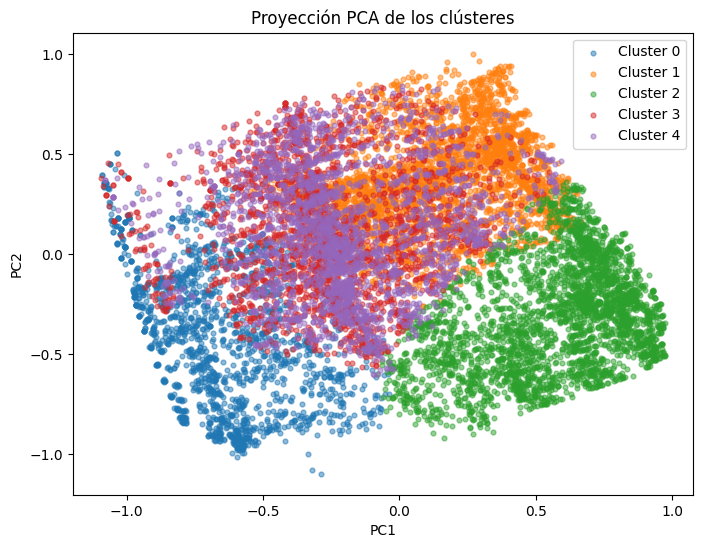

In [187]:
plt.figure(figsize=(8,6))
for cluster_id in sorted(df_resultados["cluster"].unique()):
    subset = df_resultados[df_resultados["cluster"] == cluster_id]
    plt.scatter(subset["PC1"], subset["PC2"], s=12, alpha=0.5, label=f"Cluster {cluster_id}")

plt.title("Proyección PCA de los clústeres")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

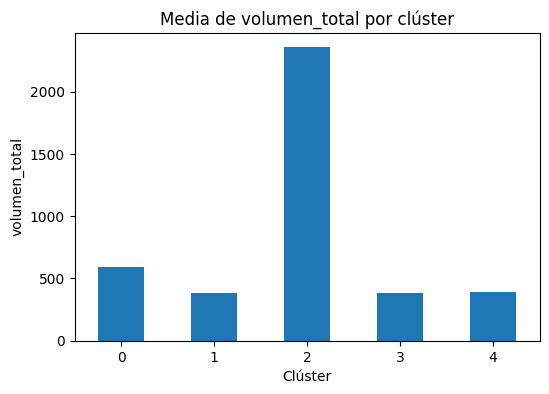

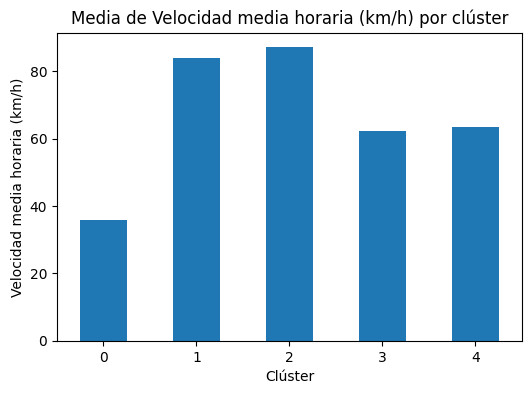

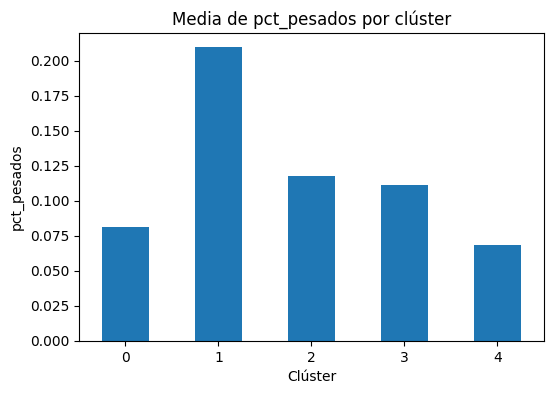

In [188]:
variables_plot = ["volumen_total", "Velocidad media horaria (km/h)", "pct_pesados"]
medias_plot = df_resultados.groupby("cluster")[variables_plot].mean()

for col in variables_plot:
    plt.figure(figsize=(6,4))
    medias_plot[col].plot(kind="bar")
    plt.title(f"Media de {col} por clúster")
    plt.xlabel("Clúster")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    plt.show()

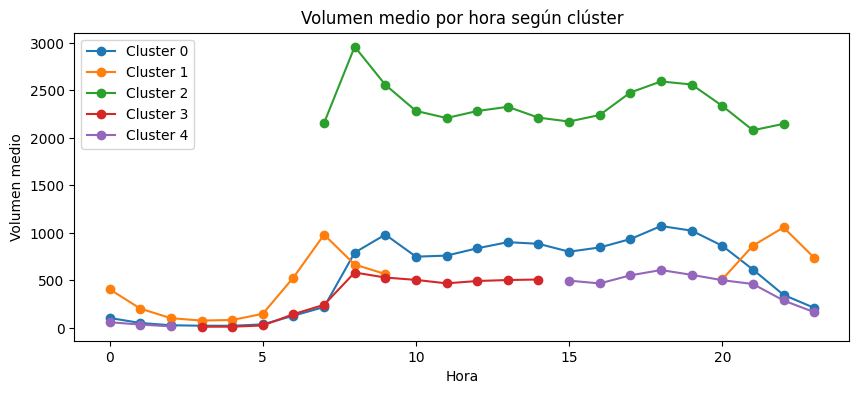

In [189]:
tabla_horaria_cluster = (
    df_resultados.groupby(["cluster", "hora_num"])["volumen_total"]
    .mean()
    .unstack(0)
)

plt.figure(figsize=(10,4))
for cluster in tabla_horaria_cluster.columns:
    plt.plot(tabla_horaria_cluster.index, tabla_horaria_cluster[cluster], marker="o", label=f"Cluster {cluster}")

plt.title("Volumen medio por hora según clúster")
plt.xlabel("Hora")
plt.ylabel("Volumen medio")
plt.legend()
plt.show()

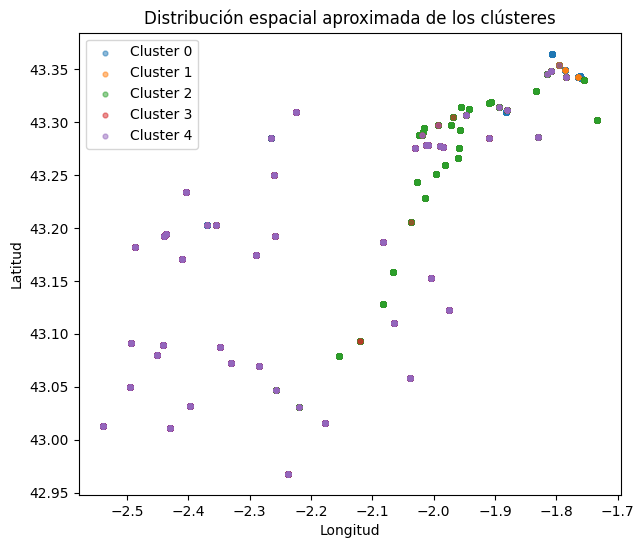

In [190]:
plt.figure(figsize=(7,6))
for cluster_id in sorted(df_resultados["cluster"].unique()):
    subset = df_resultados[df_resultados["cluster"] == cluster_id]
    plt.scatter(subset["X"], subset["Y"], s=12, alpha=0.5, label=f"Cluster {cluster_id}")

plt.title("Distribución espacial aproximada de los clústeres")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.show()

In [191]:
df_resultados.to_csv(CSV_RESULTADOS_PATH, index=False)
print("CSV de resultados guardado en:", CSV_RESULTADOS_PATH)

CSV de resultados guardado en: /home/jorgegmen/Documentos/GitHub/ML-TA-2025-2026-JorgeLopezGomez/P2_Clustering/ResultadoFinal/20251020_resultados_clustering.csv


# 9. Conclusiones finales

En este proyecto he implementado de principio a fin un *pipeline* de aprendizaje no supervisado riguroso, logrando perfilar el tráfico de Gipuzkoa con un enfoque matemático sólido.

A nivel de arquitectura de datos y preprocesamiento, he aplicado decisiones analíticas avanzadas:
1. **Conservación de registros valiosos (Imputación espacial-temporal):** En lugar de destruir registros de carreteras sin flujo en ciertas horas o sin sensores de velocidad, imputé los nulos mediante un **K-Nearest Neighbors (KNNImputer)**. Para que la distancia Euclídea del imputador fuera algorítmicamente justa, apliqué previamente un `MinMaxScaler`. Esto asegura que el algoritmo encuentre las estaciones más similares valorando por igual la hora, las coordenadas GPS, el volumen y la velocidad.
2. **Eliminación de Multicolinealidad (PCA y KMeans limpios):** Se ha diseñado cuidadosamente el espacio de variables de entrada para evitar la "trampa de las variables ficticias". Al descartar variables como `volumen_ligeros` y `volumen_pesados` (cuya suma es exacta a `volumen_total`), o el conjunto completo de porcentajes de velocidad (que suman 1 o 100%), se ha garantizado que ninguna dimensión domine artificialmente el cálculo de distancias. El modelo se basa puramente en varianza independiente.
3. **Generación de dos CSV diferenciados:** `datos_trafico_20251020.csv` como tabla de datos raw integrada (fuente de la verdad) y `20251020_resultados_clustering.csv` como producto analítico imputado, categorizado y escalado.

En el modelado, tras reducir la dimensionalidad con PCA (explicando más del 90% de la varianza), comparé **K-Means, DBSCAN y Agglomerative Clustering**. 

**El algoritmo claro ganador ha sido K-Means.**
Para seleccionarlo, diseñé una lógica de evaluación estricta: penalicé a los algoritmos que generaban un exceso de observaciones no agrupadas o "ruido". DBSCAN, pese a su utilidad espacial, tiende a perder en torno al 40% de los registros vitales de nuestra red. K-Means, en cambio, logró segmentar el 100% de la red de tráfico manteniendo una puntuación de separación geométrica (*Silhouette*) excelente y generando clústeres reales que distinguen con precisión las horas punta, las zonas de tráfico pesado y las vías de flujo de alta velocidad.

# 10. Bibliografía

- Diputación Foral de Gipuzkoa. (2025). *Datos abiertos de tráfico: volumen*. Gipuzkoairekia. https://www.gipuzkoairekia.eus/es/datu-irekien-katalogoa/-/openDataSearcher/detail/detailView/07c8a249-c1ba-4a77-bed3-d174980f652e

- Diputación Foral de Gipuzkoa. (2025). *Datos abiertos de tráfico: velocidad*. Gipuzkoairekia. https://www.gipuzkoairekia.eus/es/datu-irekien-katalogoa/-/openDataSearcher/detail/detailView/8d383e31-562a-4abb-bd78-0c1eb139e203

- Diputación Foral de Gipuzkoa. (2025). *Datos abiertos de tráfico: estaciones*. Gipuzkoairekia. https://www.gipuzkoairekia.eus/es/datu-irekien-katalogoa/-/openDataSearcher/detail/detailView/e3a9c1a7-5705-4af7-a8a0-f59525d61f95